### Linear Regression Machine Learning Project for House Price Prediction

#### Problem Understanding

#### Domain Understanding

#### Import (Libraries)

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

#### Exploratory Data Analysis (EDA)

##### 1) Data Collection

In [3]:
house_data = pd.read_csv('house_price_prediction_dataset.csv')
house_data

,Area,Bedrooms,Bathrooms,Stories,Parking,Age,City,Furnishing,Main Road,Guest Room,Basement,Water Supply,Air Conditioning,Preferred Tenant,Locality Rating,Price
0,1260,4,3,2,1,24,Pune,Semi-Furnished,Yes,Yes,Yes,Both,No,Company,4,1274350
1,5790,2,1,1,1,7,Kolkata,Unfurnished,Yes,Yes,Yes,Both,Yes,Bachelor,5,1094846
2,5626,5,2,3,0,15,Chennai,Semi-Furnished,No,Yes,Yes,Corporation,Yes,Company,6,1495933
3,5591,1,1,1,1,47,Delhi,Furnished,Yes,No,Yes,Borewell,No,Company,3,1003442
4,4172,5,1,1,1,44,Delhi,Unfurnished,No,No,No,Borewell,Yes,Bachelor,1,1306676
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1995,4323,1,1,2,0,23,Kolkata,Unfurnished,Yes,Yes,No,Borewell,Yes,Company,6,768553
1996,4803,4,2,1,1,8,Kolkata,Furnished,No,No,Yes,Both,No,Company,2,1117994
1997,5855,5,2,3,0,6,Kolkata,Furnished,No,Yes,No,Borewell,No,Bachelor,4,1800277
1998,2369,3,3,2,2,15,Chennai,Furnished,Yes,No,Yes,Both,Yes,Family,7,1547695


In [4]:
house_data.head()

,Area,Bedrooms,Bathrooms,Stories,Parking,Age,City,Furnishing,Main Road,Guest Room,Basement,Water Supply,Air Conditioning,Preferred Tenant,Locality Rating,Price
0,1260,4,3,2,1,24,Pune,Semi-Furnished,Yes,Yes,Yes,Both,No,Company,4,1274350
1,5790,2,1,1,1,7,Kolkata,Unfurnished,Yes,Yes,Yes,Both,Yes,Bachelor,5,1094846
2,5626,5,2,3,0,15,Chennai,Semi-Furnished,No,Yes,Yes,Corporation,Yes,Company,6,1495933
3,5591,1,1,1,1,47,Delhi,Furnished,Yes,No,Yes,Borewell,No,Company,3,1003442
4,4172,5,1,1,1,44,Delhi,Unfurnished,No,No,No,Borewell,Yes,Bachelor,1,1306676


In [5]:
house_data.tail()

,Area,Bedrooms,Bathrooms,Stories,Parking,Age,City,Furnishing,Main Road,Guest Room,Basement,Water Supply,Air Conditioning,Preferred Tenant,Locality Rating,Price
1995,4323,1,1,2,0,23,Kolkata,Unfurnished,Yes,Yes,No,Borewell,Yes,Company,6,768553
1996,4803,4,2,1,1,8,Kolkata,Furnished,No,No,Yes,Both,No,Company,2,1117994
1997,5855,5,2,3,0,6,Kolkata,Furnished,No,Yes,No,Borewell,No,Bachelor,4,1800277
1998,2369,3,3,2,2,15,Chennai,Furnished,Yes,No,Yes,Both,Yes,Family,7,1547695
1999,3193,5,2,1,0,18,Pune,Unfurnished,Yes,Yes,No,Corporation,Yes,Bachelor,1,1286827


##### 2) Basic Data Understanding

In [7]:
house_data.shape

(2000, 16)

In [8]:
house_data.size

32000

In [10]:
house_data.columns

Index(['Area', 'Bedrooms', 'Bathrooms', 'Stories', 'Parking', 'Age', 'City',
       'Furnishing', 'Main Road', 'Guest Room', 'Basement', 'Water Supply',
       'Air Conditioning', 'Preferred Tenant', 'Locality Rating', 'Price'],
      dtype='object')

In [14]:
house_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2000 entries, 0 to 1999
Data columns (total 16 columns):
 #   Column            Non-Null Count  Dtype 
---  ------            --------------  ----- 
 0   Area              2000 non-null   int64 
 1   Bedrooms          2000 non-null   int64 
 2   Bathrooms         2000 non-null   int64 
 3   Stories           2000 non-null   int64 
 4   Parking           2000 non-null   int64 
 5   Age               2000 non-null   int64 
 6   City              2000 non-null   object
 7   Furnishing        2000 non-null   object
 8   Main Road         2000 non-null   object
 9   Guest Room        2000 non-null   object
 10  Basement          2000 non-null   object
 11  Water Supply      2000 non-null   object
 12  Air Conditioning  2000 non-null   object
 13  Preferred Tenant  2000 non-null   object
 14  Locality Rating   2000 non-null   int64 
 15  Price             2000 non-null   int64 
dtypes: int64(8), object(8)
memory usage: 250.1+ KB


##### 3) Statistical Summary

In [19]:
house_data.describe()

,Area,Bedrooms,Bathrooms,Stories,Parking,Age,Locality Rating,Price
count,2000.000000,2000.000000,2000.00000,2000.000000,2000.000000,2000.000000,2000.000000,2.000000e+03
mean,3238.081000,3.031000,2.02150,1.996000,0.990500,24.008500,5.357500,1.245014e+06
std,1604.510239,1.427255,0.81263,0.811981,0.806682,14.319076,2.843015,3.001744e+05
min,401.000000,1.000000,1.00000,1.000000,0.000000,0.000000,1.000000,3.346350e+05
25%,1860.000000,2.000000,1.00000,1.000000,0.000000,12.000000,3.000000,1.035278e+06
50%,3271.500000,3.000000,2.00000,2.000000,1.000000,24.000000,5.000000,1.246602e+06
75%,4599.750000,4.000000,3.00000,3.000000,2.000000,36.000000,8.000000,1.453607e+06
max,5996.000000,5.000000,3.00000,3.000000,2.000000,49.000000,10.000000,2.225409e+06


##### 4) Missing Value Analysis

In [22]:
house_data.isnull().sum()

Area                0
Bedrooms            0
Bathrooms           0
Stories             0
Parking             0
Age                 0
City                0
Furnishing          0
Main Road           0
Guest Room          0
Basement            0
Water Supply        0
Air Conditioning    0
Preferred Tenant    0
Locality Rating     0
Price               0
dtype: int64

##### 5) Duplicate Data Check

In [25]:
house_data.duplicated().sum()

np.int64(0)

##### 6) Univariate Analysis

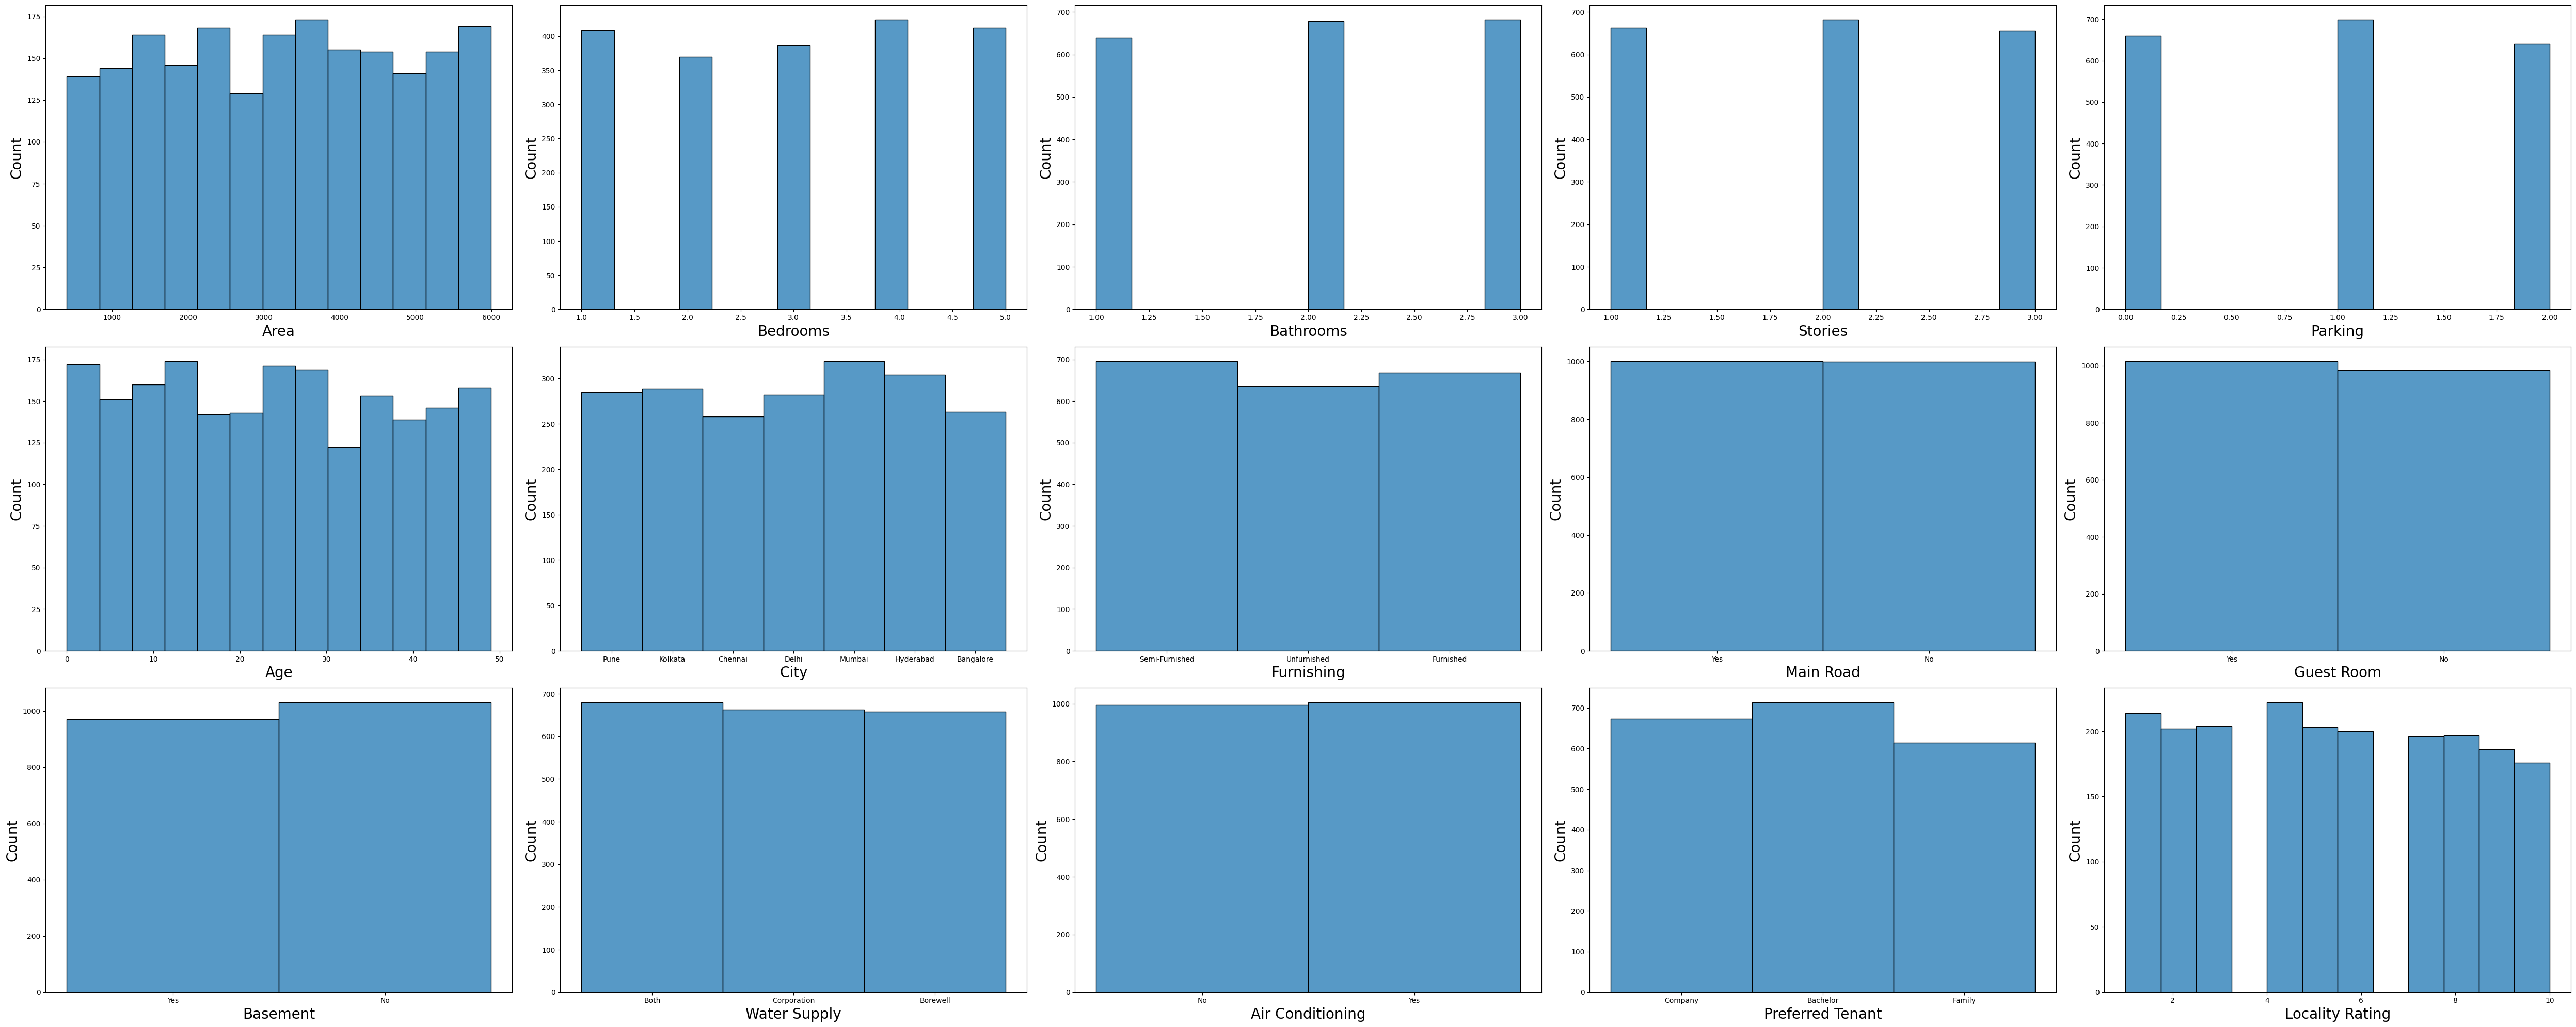

In [50]:
# Uni-variant
plt.figure(figsize=(50,20),facecolor='white')
plotnumber=1

for column in house_data:
    if plotnumber<=15: # 15 columns
        ax=plt.subplot(3,5,plotnumber) # 3 x 5 is refers columns = 15
        sns.histplot(house_data[column])
        plt.xlabel(column,fontsize=20)
        plt.ylabel('Count',fontsize=20)
    plotnumber+=1
plt.tight_layout()

<Axes: xlabel='Price', ylabel='Count'>

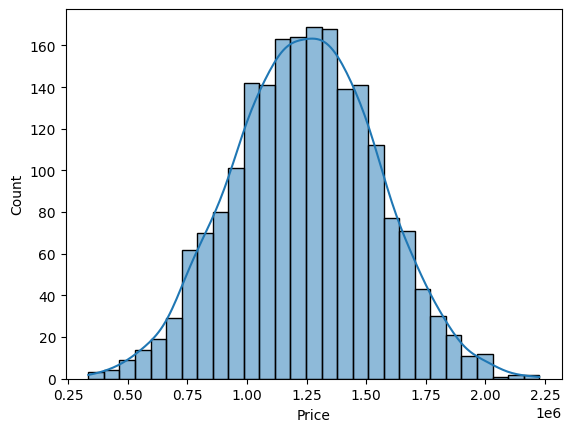

In [48]:
sns.histplot(house_data['Price'],kde='True')

In [51]:
house_data.columns

Index(['Area', 'Bedrooms', 'Bathrooms', 'Stories', 'Parking', 'Age', 'City',
       'Furnishing', 'Main Road', 'Guest Room', 'Basement', 'Water Supply',
       'Air Conditioning', 'Preferred Tenant', 'Locality Rating', 'Price'],
      dtype='object')

##### 7) Bivariate Analysis

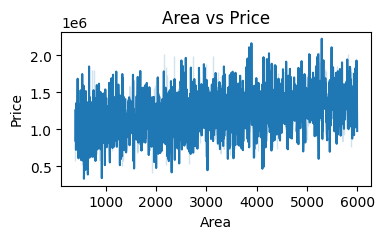

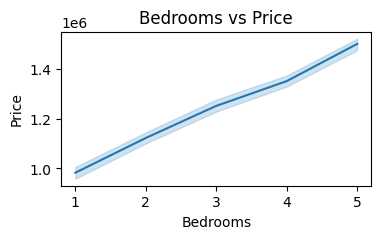

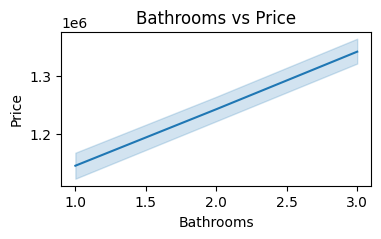

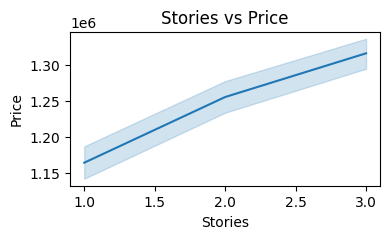

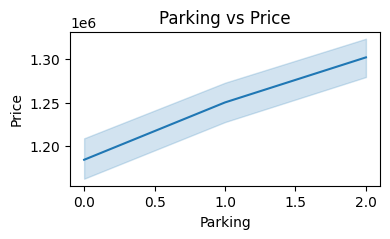

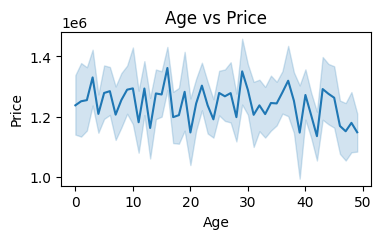

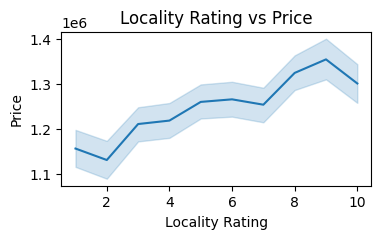

In [64]:
import seaborn as sns
import matplotlib.pyplot as plt

num_cols = ['Area','Bedrooms','Bathrooms','Stories','Parking','Age','Locality Rating','Price']

for col in num_cols:
    if col != 'Price':
        plt.figure(figsize=(4,2))
        sns.lineplot(x=house_data[col], y=house_data['Price'])
        plt.title(f"{col} vs Price")
        plt.show()

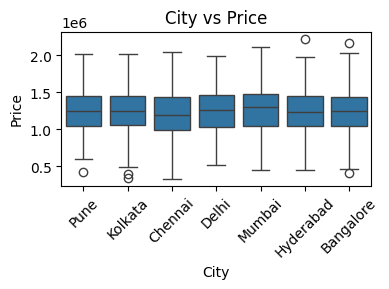

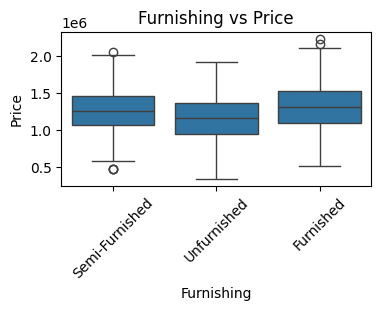

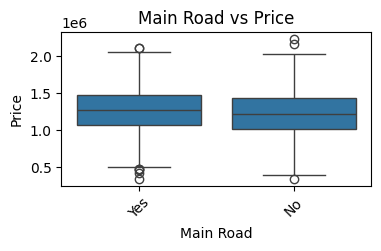

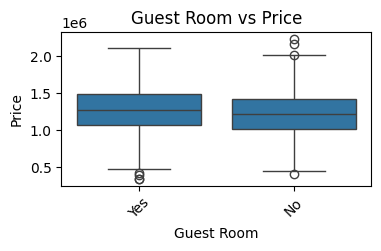

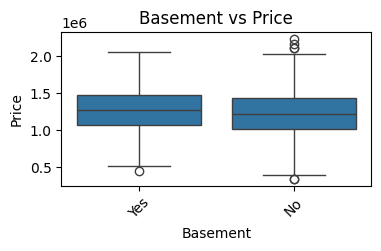

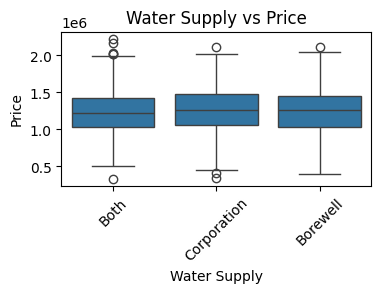

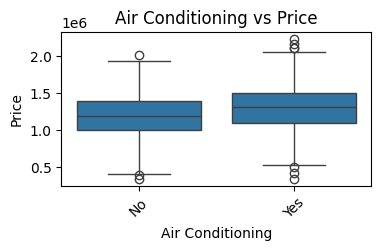

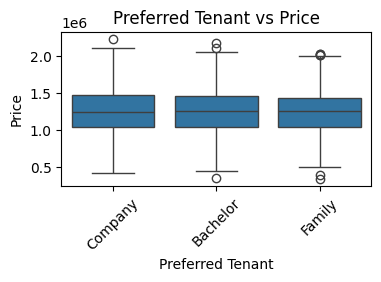

In [66]:
cat_cols = ['City','Furnishing','Main Road','Guest Room','Basement',
            'Water Supply','Air Conditioning','Preferred Tenant']

for col in cat_cols:
    plt.figure(figsize=(4,2))
    sns.boxplot(x=house_data[col], y=house_data['Price'])
    plt.title(f"{col} vs Price")
    plt.xticks(rotation=45)
    plt.show()

##### 8) Multivariate Analysis

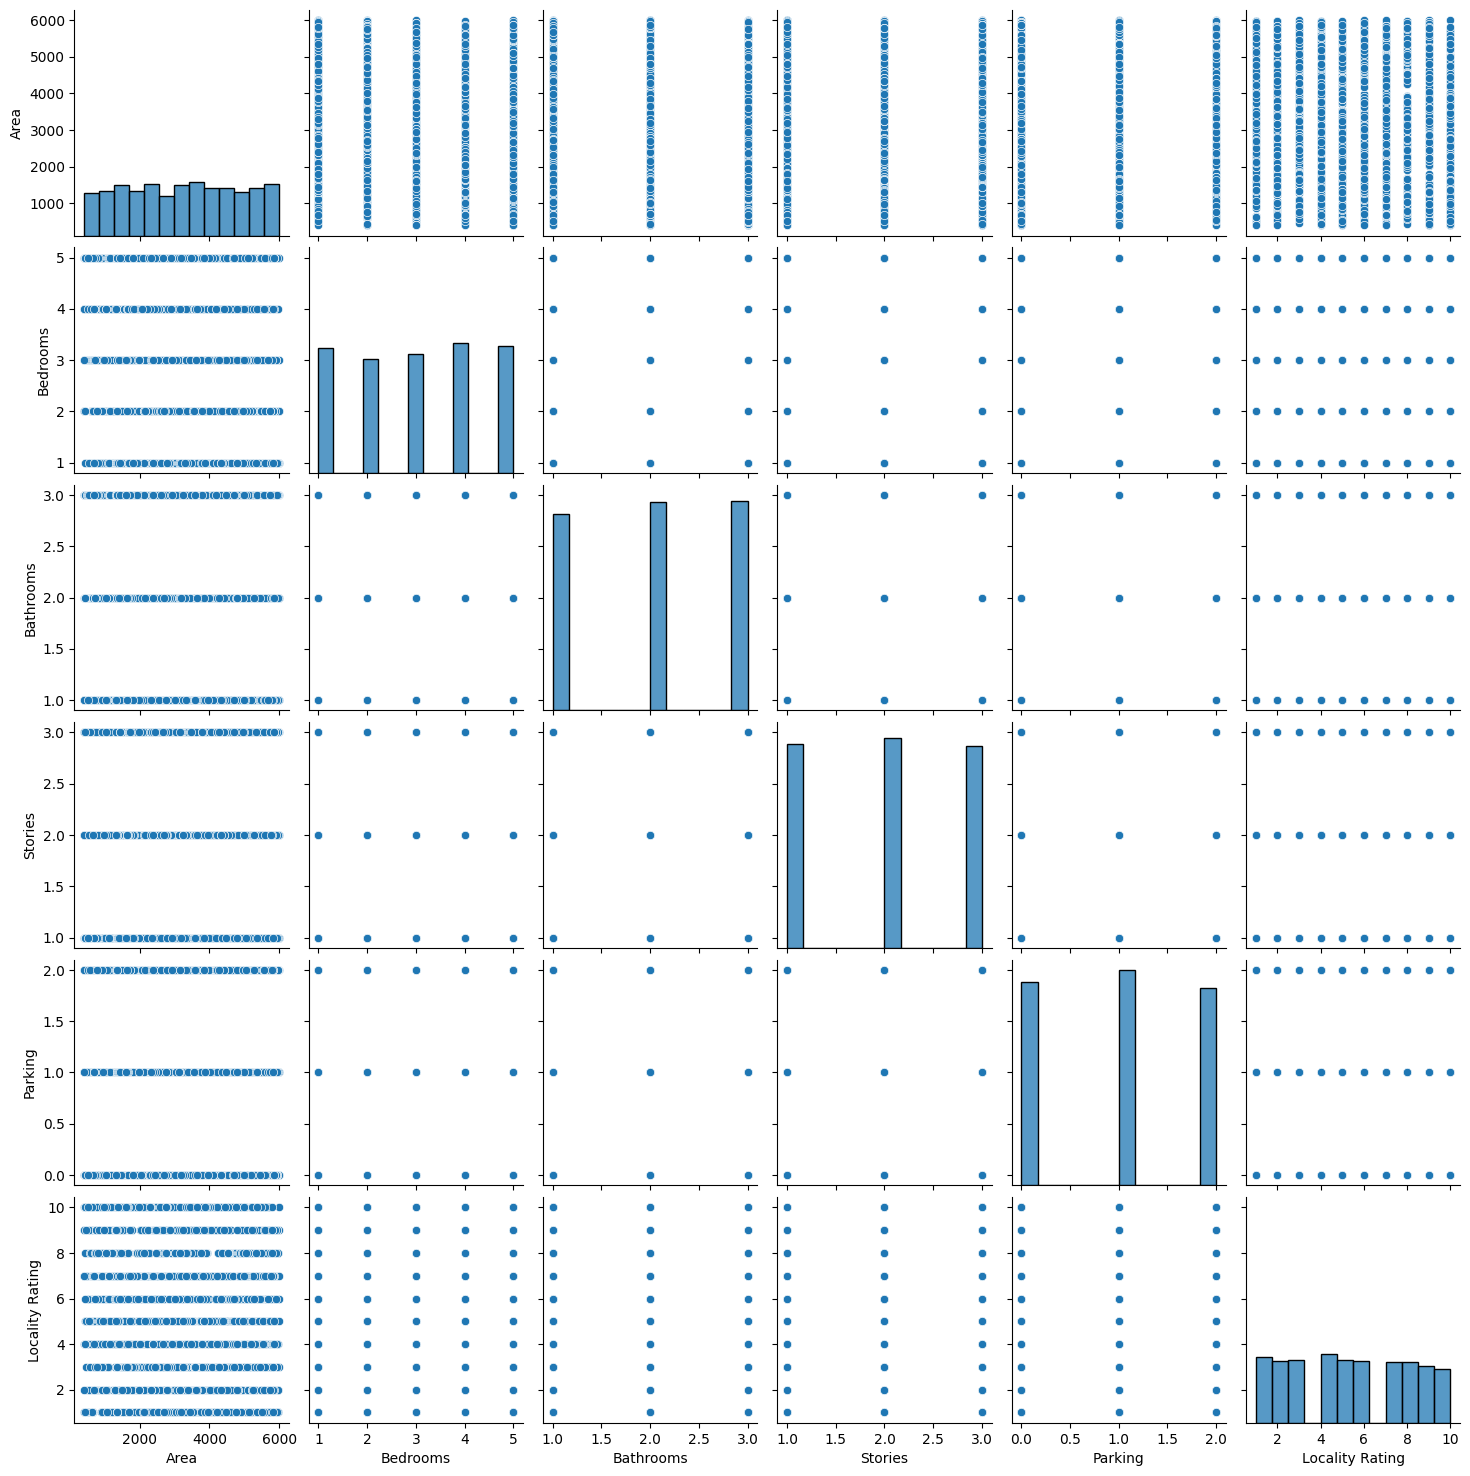

In [75]:
sns.pairplot(house_data[['Area','Bedrooms','Bathrooms', 'Stories', 'Parking', 'City','Locality Rating']])

##### 9) Outlier Detection

<Axes: ylabel='Price'>

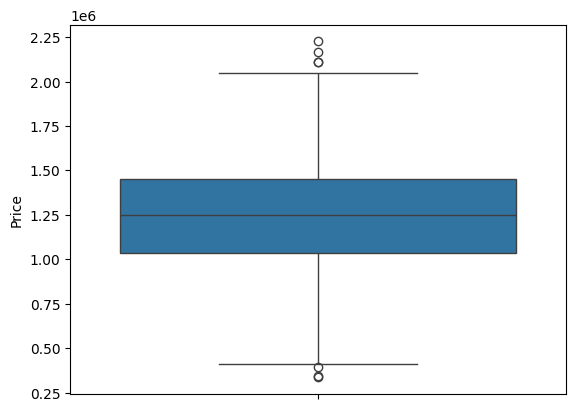

In [6]:
# BOXPLOT METHOD
sns.boxplot(house_data["Price"])

In [7]:
# Taking Z-score Method because My Price column datas are in the Normal Distribution

from scipy import stats
import numpy as np

z_scores = np.abs(stats.zscore(house_data['Price']))

outliers = house_data[z_scores > 3]

print("Number of Outliers:", len(outliers))

Number of Outliers: 4


In [8]:
house_data_clean = house_data[z_scores < 3]

In [9]:
house_data_clean

,Area,Bedrooms,Bathrooms,Stories,Parking,Age,City,Furnishing,Main Road,Guest Room,Basement,Water Supply,Air Conditioning,Preferred Tenant,Locality Rating,Price
0,1260,4,3,2,1,24,Pune,Semi-Furnished,Yes,Yes,Yes,Both,No,Company,4,1274350
1,5790,2,1,1,1,7,Kolkata,Unfurnished,Yes,Yes,Yes,Both,Yes,Bachelor,5,1094846
2,5626,5,2,3,0,15,Chennai,Semi-Furnished,No,Yes,Yes,Corporation,Yes,Company,6,1495933
3,5591,1,1,1,1,47,Delhi,Furnished,Yes,No,Yes,Borewell,No,Company,3,1003442
4,4172,5,1,1,1,44,Delhi,Unfurnished,No,No,No,Borewell,Yes,Bachelor,1,1306676
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1995,4323,1,1,2,0,23,Kolkata,Unfurnished,Yes,Yes,No,Borewell,Yes,Company,6,768553
1996,4803,4,2,1,1,8,Kolkata,Furnished,No,No,Yes,Both,No,Company,2,1117994
1997,5855,5,2,3,0,6,Kolkata,Furnished,No,Yes,No,Borewell,No,Bachelor,4,1800277
1998,2369,3,3,2,2,15,Chennai,Furnished,Yes,No,Yes,Both,Yes,Family,7,1547695


<Axes: ylabel='Price'>

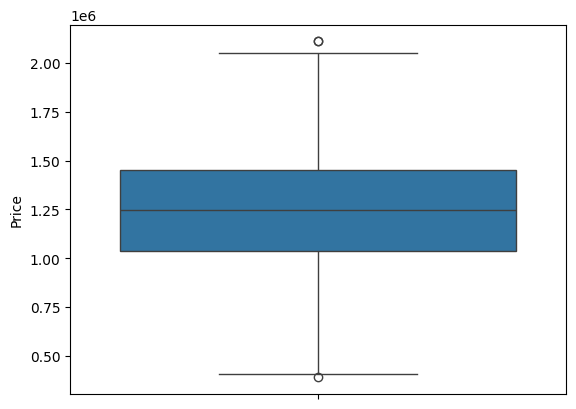

In [10]:
# BOXPLOT METHOD
sns.boxplot(house_data_clean["Price"])

##### 10) Correlation Analysis

In [93]:
house_data_clean.corr(numeric_only=True)

,Area,Bedrooms,Bathrooms,Stories,Parking,Age,Locality Rating,Price
Area,1.000000,0.016988,0.029540,-0.014331,-0.016954,0.004845,-0.008107,0.335510
Bedrooms,0.016988,1.000000,0.005925,-0.017219,-0.031137,0.024625,0.043260,0.598850
Bathrooms,0.029540,0.005925,1.000000,-0.053842,0.014822,-0.013076,-0.025402,0.264586
Stories,-0.014331,-0.017219,-0.053842,1.000000,-0.020731,-0.013362,0.014964,0.200222
Parking,-0.016954,-0.031137,0.014822,-0.020731,1.000000,-0.003793,-0.054998,0.155113
Age,0.004845,0.024625,-0.013076,-0.013362,-0.003793,1.000000,0.023050,-0.053383
Locality Rating,-0.008107,0.043260,-0.025402,0.014964,-0.054998,0.023050,1.000000,0.202651
Price,0.335510,0.598850,0.264586,0.200222,0.155113,-0.053383,0.202651,1.000000


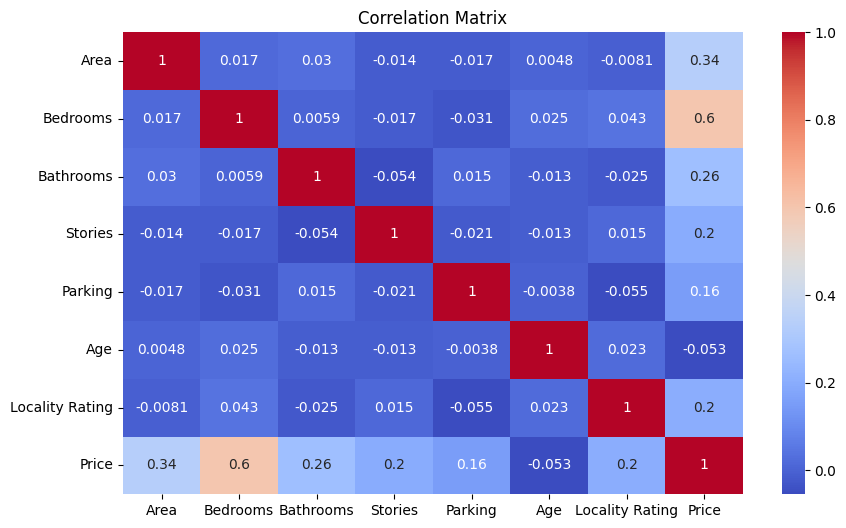

In [94]:
plt.figure(figsize=(10,6))
sns.heatmap(house_data_clean.corr(numeric_only=True), annot=True, cmap='coolwarm')
plt.title("Correlation Matrix")
plt.show()

### Data Preprocessing & Feature Engineering

##### 1) Check Duplicates

In [95]:
house_data_clean.duplicated().sum()

np.int64(0)

##### 2) Split Data

In [11]:
X = house_data_clean.drop("Price", axis=1)
y = house_data_clean["Price"]

In [12]:
X = pd.get_dummies(X, drop_first=True)

In [13]:
X.head()

,Area,Bedrooms,Bathrooms,Stories,Parking,Age,Locality Rating,City_Chennai,City_Delhi,City_Hyderabad,...,Furnishing_Semi-Furnished,Furnishing_Unfurnished,Main Road_Yes,Guest Room_Yes,Basement_Yes,Water Supply_Both,Water Supply_Corporation,Air Conditioning_Yes,Preferred Tenant_Company,Preferred Tenant_Family
0,1260,4,3,2,1,24,4,False,False,False,...,True,False,True,True,True,True,False,False,True,False
1,5790,2,1,1,1,7,5,False,False,False,...,False,True,True,True,True,True,False,True,False,False
2,5626,5,2,3,0,15,6,True,False,False,...,True,False,False,True,True,False,True,True,True,False
3,5591,1,1,1,1,47,3,False,True,False,...,False,False,True,False,True,False,False,False,True,False
4,4172,5,1,1,1,44,1,False,True,False,...,False,True,False,False,False,False,False,True,False,False


In [14]:
y

0       1274350
1       1094846
2       1495933
3       1003442
4       1306676
         ...   
1995     768553
1996    1117994
1997    1800277
1998    1547695
1999    1286827
Name: Price, Length: 1996, dtype: int64

##### 3) Train-Test Split

In [15]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [16]:
X_train

,Area,Bedrooms,Bathrooms,Stories,Parking,Age,Locality Rating,City_Chennai,City_Delhi,City_Hyderabad,...,Furnishing_Semi-Furnished,Furnishing_Unfurnished,Main Road_Yes,Guest Room_Yes,Basement_Yes,Water Supply_Both,Water Supply_Corporation,Air Conditioning_Yes,Preferred Tenant_Company,Preferred Tenant_Family
1832,1960,4,2,2,0,30,6,True,False,False,...,False,False,False,False,False,False,False,True,False,True
678,1545,5,3,1,1,31,10,False,True,False,...,False,False,False,False,False,True,False,True,False,False
1084,2588,2,2,2,0,12,5,False,False,False,...,False,True,False,True,True,True,False,False,True,False
1562,3420,5,3,1,0,34,4,False,False,False,...,True,False,False,True,False,False,False,True,True,False
365,3206,4,3,1,1,16,8,False,False,False,...,False,True,False,False,True,True,False,False,False,True
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1131,2522,4,1,3,2,13,4,False,False,False,...,False,True,False,False,False,False,True,False,True,False
1295,5897,3,2,3,0,43,1,False,False,True,...,False,True,True,False,False,True,False,True,False,False
861,5831,4,3,2,1,19,8,False,False,False,...,False,True,False,True,False,True,False,False,True,False
1461,3911,1,1,3,2,28,8,False,True,False,...,False,True,True,True,True,False,False,False,True,False


In [17]:
X_test

,Area,Bedrooms,Bathrooms,Stories,Parking,Age,Locality Rating,City_Chennai,City_Delhi,City_Hyderabad,...,Furnishing_Semi-Furnished,Furnishing_Unfurnished,Main Road_Yes,Guest Room_Yes,Basement_Yes,Water Supply_Both,Water Supply_Corporation,Air Conditioning_Yes,Preferred Tenant_Company,Preferred Tenant_Family
890,4606,1,3,3,2,16,1,True,False,False,...,False,True,False,False,False,False,False,True,False,True
1676,438,5,1,3,1,5,8,False,False,False,...,True,False,False,False,False,False,False,False,False,False
414,5152,2,1,2,0,0,6,False,False,False,...,False,False,True,False,False,True,False,False,False,True
1429,438,5,3,1,2,37,10,False,False,False,...,False,True,True,True,False,True,False,False,True,False
850,702,3,2,1,1,47,8,False,False,False,...,False,True,False,False,True,False,False,False,False,True
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
261,4899,5,3,1,2,32,6,False,False,False,...,False,False,True,False,True,True,False,False,True,False
576,3382,1,1,3,0,34,2,True,False,False,...,True,False,True,True,False,True,False,True,False,True
964,2619,3,1,2,1,32,3,False,False,False,...,False,True,True,False,True,True,False,True,True,False
240,2202,5,3,2,1,8,6,False,False,True,...,False,False,False,False,True,False,True,False,False,True


##### 4) Feature Scaling

In [102]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

### Model Creation

##### Linear Regression

In [18]:
from sklearn.linear_model import LinearRegression

LR=LinearRegression() 
LR.fit(X_train,y_train)

y_predict=LR.predict(X_test)

In [19]:
y_test

890     1279132
1676    1053241
414      909019
1429    1478852
850      773627
         ...   
261     1813460
576     1001727
964      938307
240     1065976
1381    1206641
Name: Price, Length: 400, dtype: int64

In [20]:
y_predict

array([1121965.40455034, 1299902.75837728, 1096559.78332726,
       1364777.6165151 ,  875770.84423443,  676175.5289855 ,
        671855.97319658, 1063378.11423932, 1542322.32099438,
        924267.53157494, 1139990.06164886,  911811.81456143,
       1153913.14856494, 1165988.92670919, 1542570.38889586,
        990643.23790324, 1150458.10707941, 1060368.38728225,
       1130453.28954475,  927078.6327766 , 1666365.5543847 ,
        629130.71664282,  947255.48875822,  955837.7206194 ,
       1056095.033449  ,  968387.29997339,  989588.64581353,
       1343526.02975498, 1157302.29292011, 1051517.19777543,
        869933.15242797, 1074550.92217214, 1441548.3948989 ,
       1670078.93521196, 1349205.16564402,  729336.23300557,
       1260223.22390826, 1295054.03424237, 1523157.5578729 ,
       1628739.12102055, 1439644.16294015,  938765.82412042,
       1643599.09467929, 1311771.81353906, 1235183.49972573,
       1320016.31209776, 1218354.46402008, 1428375.29855994,
        760663.63038481,

### Model Evaluation

In [21]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score


mae = mean_absolute_error(y_test, y_predict)
mse = mean_squared_error(y_test, y_predict)
r2 = r2_score(y_test, y_predict)

print("MAE:",mae)
print("MSE:",mse)
print("R2 Score:",r2)

MAE: 122406.76334197354
MSE: 22898532958.72525
R2 Score: 0.7502310759587025


In [23]:
X_test.head()

,Area,Bedrooms,Bathrooms,Stories,Parking,Age,Locality Rating,City_Chennai,City_Delhi,City_Hyderabad,...,Furnishing_Semi-Furnished,Furnishing_Unfurnished,Main Road_Yes,Guest Room_Yes,Basement_Yes,Water Supply_Both,Water Supply_Corporation,Air Conditioning_Yes,Preferred Tenant_Company,Preferred Tenant_Family
890,4606,1,3,3,2,16,1,True,False,False,...,False,True,False,False,False,False,False,True,False,True
1676,438,5,1,3,1,5,8,False,False,False,...,True,False,False,False,False,False,False,False,False,False
414,5152,2,1,2,0,0,6,False,False,False,...,False,False,True,False,False,True,False,False,False,True
1429,438,5,3,1,2,37,10,False,False,False,...,False,True,True,True,False,True,False,False,True,False
850,702,3,2,1,1,47,8,False,False,False,...,False,True,False,False,True,False,False,False,False,True


In [24]:
X_test.shape

(400, 23)

In [25]:
## calculation of adjusted r2 score
adjusted_r2 = 1-(1-r2)*(400-1)/(400-23-1)
adjusted_r2 

0.7349526577327721

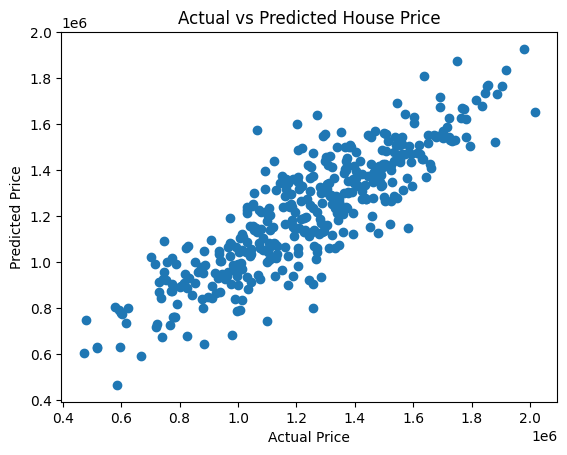

In [27]:
import matplotlib.pyplot as plt

plt.scatter(y_test, y_predict)
plt.xlabel("Actual Price")
plt.ylabel("Predicted Price")
plt.title("Actual vs Predicted House Price")
plt.show()

In [30]:
house_data.columns

Index(['Area', 'Bedrooms', 'Bathrooms', 'Stories', 'Parking', 'Age', 'City',
       'Furnishing', 'Main Road', 'Guest Room', 'Basement', 'Water Supply',
       'Air Conditioning', 'Preferred Tenant', 'Locality Rating', 'Price'],
      dtype='object')

In [36]:
comparison = pd.DataFrame({
"Actual Price": y_test.values,
"Predicted Price": y_predict
})

comparison["Error"] = comparison["Actual Price"] - comparison["Predicted Price"]

print(comparison.head(10))

   Actual Price  Predicted Price          Error
0       1279132     1.121965e+06  157166.595450
1       1053241     1.299903e+06 -246661.758377
2        909019     1.096560e+06 -187540.783327
3       1478852     1.364778e+06  114074.383485
4        773627     8.757708e+05 -102143.844234
5        826774     6.761755e+05  150598.471014
6        740078     6.718560e+05   68222.026803
7        964584     1.063378e+06  -98794.114239
8       1780783     1.542322e+06  238460.679006
9        743859     9.242675e+05 -180408.531575
